In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [3]:
df = pd.read_csv("optimized_waste_management_data.csv")
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [4]:
df.isna().sum()

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


In [5]:
df = df.fillna(method='ffill')

/tmp/ipykernel_2765/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [6]:
# Extract Feature to Predict
# We only use the Waste Column for forecasting
waste_data = df[['waste_volume']]

### Normalize the Data
Neural networks work better when data values are scaled between 0 and 1.

In [7]:
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(waste_data)

### Convert Data into Sequences
RNN requires sequential input.

Example:

Previous 10 days -> Predict next day

In [8]:
def create_sequences(data, seq_length):
  X = []
  Y = []
  for i in range(len(data)-seq_length):
    X.append(data[i:i+seq_length])
    Y.append(data[i+seq_length])
  return np.array(X), np.array(Y)

### Create Time Sequences


In [9]:
sequence_length=10
X,y=create_sequences(scaled_data,sequence_length)
print(X.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


### Build the RNN Model
Architecture:

Input -> RNN Layer -> Dense Output

In [10]:
model=Sequential()
model.add(SimpleRNN(50,activation="tanh",input_shape=(sequence_length,1)))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

### Split Data into Training and Testing Sets

In [11]:
split=int(0.8*len(X))
X_train=X[:split]
y_train=y[:split]
X_test=X[split:]
y_test=y[split:]

### Train the Model
We train the model for 50 epochs

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0291 - val_loss: 0.0138
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0103 - val_loss: 0.0146
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0130
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0098 - val_loss: 0.0122
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0147
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097 - val_loss: 0.0137
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0116
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0146
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0127
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0117
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0133
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_l

### Evaluate the Model

In [13]:
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0096
Test Loss: 0.009638766758143902


In [14]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


### Convert Predictions Back to Original Scale

In [15]:
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

### Plot predictions vs Actual Values

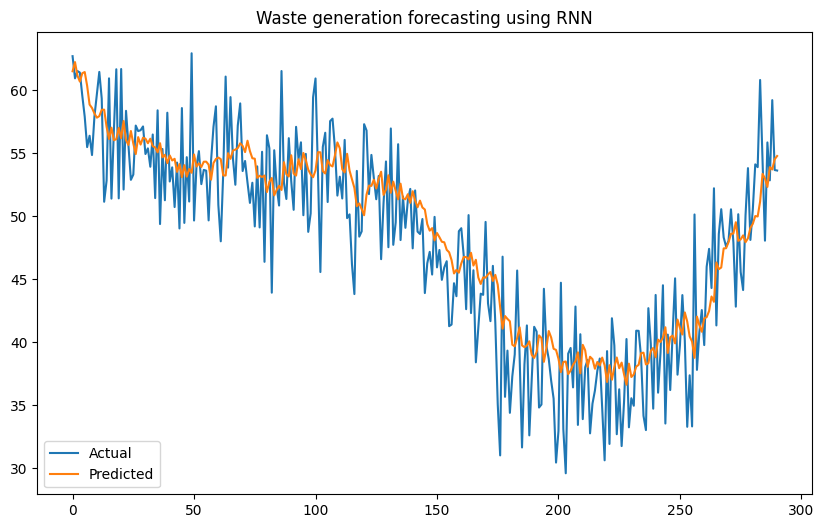

In [16]:
plt.figure(figsize=(10,6))
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title("Waste generation forecasting using RNN")
plt.legend()
plt.show()
# Two lines are close - good model